In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
# Directory containing the JSON files
directory = '/nas/longleaf/home/kbhimani/EH-Drift/Analysis/ge_det_geo_analysis/legend-detectors/germanium/diodes'

# Initialize a list to store the data
data = []

# Iterate over each file in the directory
for filename in tqdm(os.listdir(directory)):
    if filename.endswith('.json'):
        filepath = os.path.join(directory, filename)
        with open(filepath, 'r') as file:
            detector = json.load(file)
            name = detector.get('name', '')
            detector_type = detector.get('type', '')
            manufacturer = detector['production'].get('manufacturer', '')
            geometry = detector.get('geometry', {})
            
            height = geometry.get('height_in_mm', None)
            radius = geometry.get('radius_in_mm', None)
            borehole_radius = geometry.get('borehole', {}).get('radius_in_mm', None)
            borehole_depth = geometry.get('borehole', {}).get('depth_in_mm', None)
            groove_depth = geometry.get('groove', {}).get('depth_in_mm', None)
            groove_outer_radius = geometry.get('groove', {}).get('radius_in_mm', {}).get('outer', None)
            groove_inner_radius = geometry.get('groove', {}).get('radius_in_mm', {}).get('inner', None)
            pp_contact_radius = geometry.get('pp_contact', {}).get('radius_in_mm', None)
            pp_contact_depth = geometry.get('pp_contact', {}).get('depth_in_mm', None)
            taper_top_angle = geometry.get('taper', {}).get('top', {}).get('angle_in_deg', None)
            taper_top_height = geometry.get('taper', {}).get('top', {}).get('height_in_mm', None)
            taper_bottom_angle = geometry.get('taper', {}).get('bottom', {}).get('angle_in_deg', None)
            taper_bottom_height = geometry.get('taper', {}).get('bottom', {}).get('height_in_mm', None)
            
            data.append({
                'name': name,
                'type': detector_type,
                'manufacturer': manufacturer,
                'height_in_mm': height,
                'radius_in_mm': radius,
                'borehole_radius_in_mm': borehole_radius,
                'borehole_depth_in_mm': borehole_depth,
                'groove_depth_in_mm': groove_depth,
                'groove_outer_radius_in_mm': groove_outer_radius,
                'groove_inner_radius_in_mm': groove_inner_radius,
                'pp_contact_radius_in_mm': pp_contact_radius,
                'pp_contact_depth_in_mm': pp_contact_depth,
                'taper_top_angle_in_deg': taper_top_angle,
                'taper_top_height_in_mm': taper_top_height,
                'taper_bottom_angle_in_deg': taper_bottom_angle,
                'taper_bottom_height_in_mm': taper_bottom_height,
            })

# Create a DataFrame from the data
df = pd.DataFrame(data)
df['groove_width_in_mm'] = df['groove_outer_radius_in_mm'] - df['groove_inner_radius_in_mm']

100%|██████████| 125/125 [00:00<00:00, 336.97it/s]


In [2]:
len(data)

124

In [3]:
# df[df['type']=='bege']['manufacturer'].unique()
print(len(df['name'].unique()))

124


In [4]:
ppc_df = df[(df['type']=='icpc') & (df['manufacturer']=='Mirion')]
ppc_df

,name,type,manufacturer,height_in_mm,radius_in_mm,borehole_radius_in_mm,borehole_depth_in_mm,groove_depth_in_mm,groove_outer_radius_in_mm,groove_inner_radius_in_mm,pp_contact_radius_in_mm,pp_contact_depth_in_mm,taper_top_angle_in_deg,taper_top_height_in_mm,taper_bottom_angle_in_deg,taper_bottom_height_in_mm,groove_width_in_mm
71,V00048A,icpc,Mirion,80.4,37.30,5.25,47.4,2.0,13.00,10.00,10.00,0.0,0.0,0.0,0.0,0.0,3.00
72,V00048B,icpc,Mirion,80.5,36.30,5.25,56.0,2.0,12.50,7.50,7.50,0.0,0.0,0.0,0.0,0.0,5.00
73,V00050A,icpc,Mirion,80.4,37.35,5.25,40.0,2.0,13.50,9.50,9.50,0.0,1.8,40.0,0.0,0.0,4.00
74,V00050B,icpc,Mirion,85.4,36.30,5.25,53.9,2.0,13.50,9.50,9.50,0.0,0.0,0.0,0.0,0.0,4.00
75,V00074A,icpc,Mirion,82.3,38.30,5.25,52.4,2.0,13.50,9.50,9.50,0.0,0.0,0.0,0.0,0.0,4.00
85,V02160A,icpc,Mirion,65.4,39.90,4.70,33.7,2.0,15.50,11.30,11.30,0.0,6.1,20.1,0.0,0.0,4.20
86,V02160B,icpc,Mirion,59.3,41.00,4.80,30.0,2.0,13.90,10.10,10.10,0.0,0.0,0.0,0.0,0.0,3.80
87,V02162B,icpc,Mirion,90.4,40.00,4.00,54.9,3.0,15.75,10.50,10.50,0.0,1.8,25.0,0.0,0.0,5.25
88,V02166B,icpc,Mirion,95.5,40.00,4.25,61.6,2.0,13.85,9.65,9.65,0.0,0.0,0.0,0.0,0.0,4.20
89,V03421A,icpc,Mirion,85.2,43.00,4.00,45.0,2.0,15.00,12.00,12.00,0.0,45.0,1.0,45.0,1.0,3.00


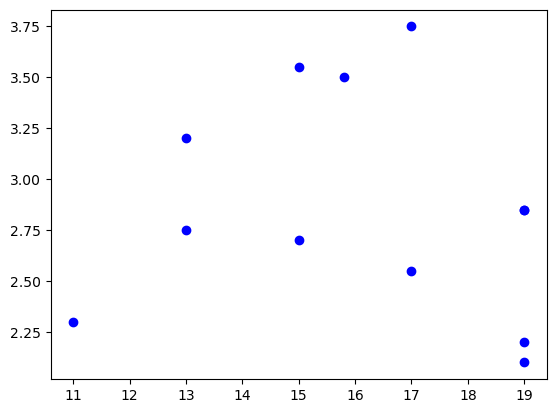

In [5]:
ppc_df = df[(df['type']=='icpc') & (df['manufacturer']=='Ortec')]
plt.plot(ppc_df['groove_inner_radius_in_mm'], ppc_df['pp_contact_radius_in_mm'],'bo')

In [6]:
# Function to plot histograms for a given feature across all detector types
def plot_histograms(feature):
    detector_types = ['bege', 'ppc', 'icpc']
    manufacturers = {
        'bege': 'Mirion',
        'ppc': 'Ortec',
        'icpc': ['Ortec', 'Mirion']
    }
    
    colors = sns.color_palette('husl', len(detector_types) + len(manufacturers['icpc']))
    
    plt.figure(figsize=(12, 8))
    
    color_idx = 0
    for i, detector_type in enumerate(detector_types, 1):
        if detector_type == 'icpc':
            for j, manufacturer in enumerate(manufacturers[detector_type], 1):
                plt.subplot(2, 2, i+j-1)
                subset = df[(df['type'] == detector_type) & (df['manufacturer'] == manufacturer)]
                sns.histplot(subset[feature].dropna(), kde=False, bins=20, color=colors[color_idx])
                color_idx += 1
                plt.title(f'Distribution of {feature} for {detector_type.upper()} detectors made by {manufacturer}')
                plt.xlabel(feature)
                plt.ylabel('Frequency')
        else:
            plt.subplot(2, 2, i)
            subset = df[df['type'] == detector_type]
            sns.histplot(subset[feature].dropna(), kde=False, bins=20, color=colors[color_idx])
            color_idx += 1
            plt.title(f'Distribution of {feature} for {detector_type.upper()} detectors')
            plt.xlabel(feature)
            plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()


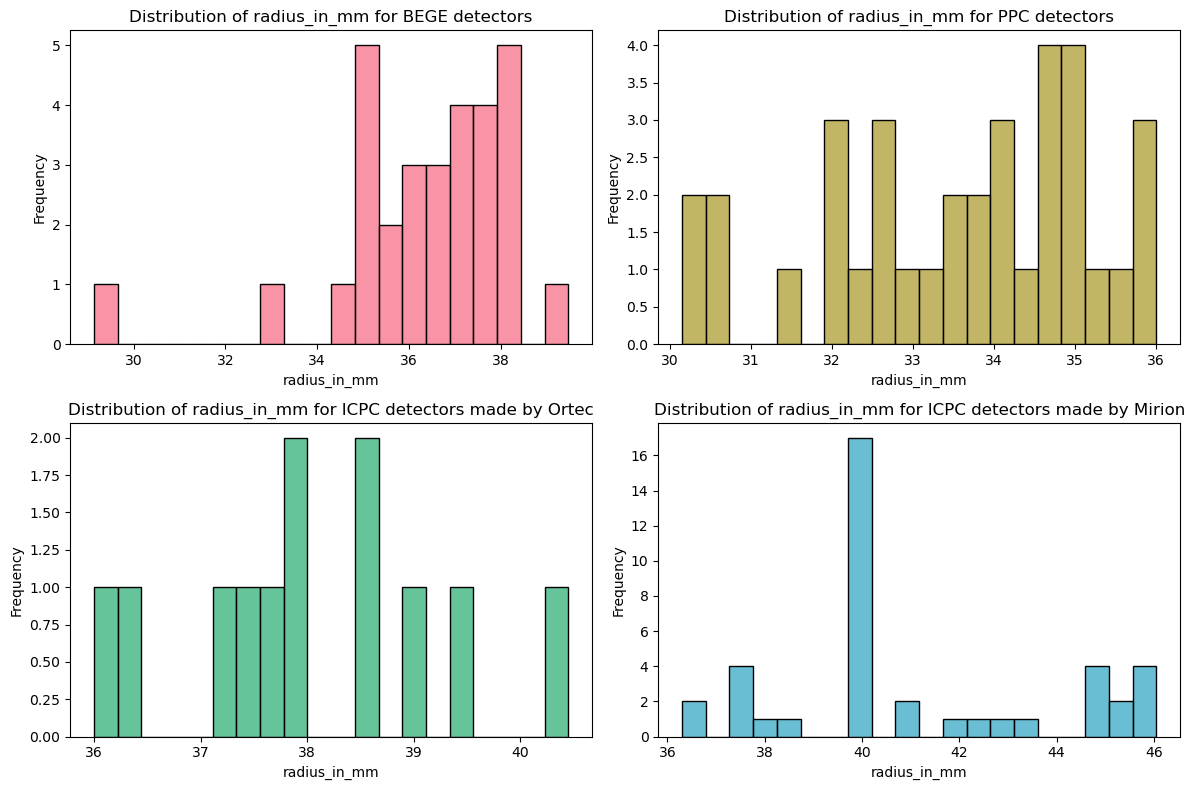

In [7]:
plot_histograms('radius_in_mm') #radius_in_mm groove_outer_radius_in_mm groove_depth_in_mm

In [8]:
# # Filter the data for Mirion ICPC detectors
# mirion_icpc_df = df[(df['manufacturer'] == 'Mirion') & (df['type'] == 'icpc')]

# # Plot comparisons of radius, groove inner radius, and point contact radius using scatter plots
# plt.figure(figsize=(18, 6))

# plt.subplot(1, 3, 1)
# sns.scatterplot(data=mirion_icpc_df, x='radius_in_mm', y='groove_inner_radius_in_mm', color='blue', alpha=0.5)
# plt.title('Radius vs Groove Inner Radius for Mirion ICPC Detectors')
# plt.xlabel('Radius (mm)')
# plt.ylabel('Groove Inner Radius (mm)')

# plt.subplot(1, 3, 2)
# sns.scatterplot(data=mirion_icpc_df, x='radius_in_mm', y='pp_contact_radius_in_mm', color='green', alpha=0.5)
# plt.title('Radius vs Point Contact Radius for Mirion ICPC Detectors')
# plt.xlabel('Radius (mm)')
# plt.ylabel('Point Contact Radius (mm)')

# plt.subplot(1, 3, 3)
# sns.scatterplot(data=mirion_icpc_df, x='groove_inner_radius_in_mm', y='pp_contact_radius_in_mm', color='red', alpha=0.5)
# plt.title('Groove Inner Radius vs Point Contact Radius for Mirion ICPC Detectors')
# plt.xlabel('Groove Inner Radius (mm)')
# plt.ylabel('Point Contact Radius (mm)')

# plt.tight_layout()
# plt.show()


In [9]:
import os
import json
from math import tan, radians
from tqdm import tqdm

def calculate_impurity_gradient(impurity_values, distances):
    """
    Calculate impurity gradient based on impurity values and distances.
    """
    if not impurity_values or not distances or len(impurity_values) < 2 or len(distances) < 2 or (distances[-1] - distances[0]) == 0:
        return 0.0
    slope = (impurity_values[-1] - impurity_values[0]) / (distances[-1] - distances[0])
    return round(slope, 4)  # Convert to 1e10 e/cm4 and round to 4 decimals


def create_siggen_config(json_file, output_dir):
    """
    Generate a SigGen config file based on detector metadata from JSON.
    """
    # Load the JSON file
    with open(json_file, 'r') as file:
        metadata = json.load(file)

    # Extract values from JSON, with default values for missing features
    xtal_length = round(metadata['geometry'].get('height_in_mm', 0), 2)
    xtal_radius = round(metadata['geometry'].get('radius_in_mm', 0), 2)
    pc_length = round(metadata['geometry'].get('pp_contact', {}).get('depth_in_mm', 0), 2)
    pc_radius = round(metadata['geometry'].get('pp_contact', {}).get('radius_in_mm', 0), 2)

    taper_top_angle = round(metadata['geometry'].get('taper', {}).get('top', {}).get('angle_in_deg', 0), 2)
    taper_top_length = round(metadata['geometry'].get('taper', {}).get('top', {}).get('height_in_mm', 0), 2)
    taper_top_width = round(taper_top_length * tan(radians(taper_top_angle)), 2)

    taper_bottom_angle = round(metadata['geometry'].get('taper', {}).get('bottom', {}).get('angle_in_deg', 0), 2)
    taper_bottom_length = round(metadata['geometry'].get('taper', {}).get('bottom', {}).get('height_in_mm', 0), 2) if taper_bottom_angle == 45 else 0
    taper_bottom_width = round(taper_bottom_length * tan(radians(taper_bottom_angle)), 2) if taper_bottom_length else 0

    borehole_depth = round(metadata['geometry'].get('borehole', {}).get('depth_in_mm', 0), 2)
    borehole_radius = round(metadata['geometry'].get('borehole', {}).get('radius_in_mm', 0), 2)
    borehole_taper_angle = round(metadata['geometry'].get('taper', {}).get('borehole', {}).get('angle_in_deg', 0), 2)
    borehole_taper_length = round(metadata['geometry'].get('taper', {}).get('borehole', {}).get('height_in_mm', 0), 2)
    borehole_taper_width = round(borehole_taper_length * tan(radians(borehole_taper_angle)), 2) if borehole_taper_length else 0

    wrap_around_radius = round(metadata['geometry'].get('groove', {}).get('radius_in_mm', {}).get('outer', 0), 2)
    ditch_depth = round(metadata['geometry'].get('groove', {}).get('depth_in_mm', 0), 2)
    ditch_thickness = round(metadata['geometry'].get('groove', {}).get('radius_in_mm', {}).get('outer', 0) -
                            metadata['geometry'].get('groove', {}).get('radius_in_mm', {}).get('inner', 0), 2)

    Li_thickness = 1.0  # Default value, could be adjusted as needed

    # Attempt to get recommended voltage from characterization data
    xtal_HV = metadata['characterization']['l200_site'].get('recommended_voltage_in_V', None)
    if xtal_HV is None:
        xtal_HV = metadata['characterization']['manufacturer'].get('recommended_voltage_in_V', None)

    if xtal_HV is None:
        print(f"Skipping detector {metadata['name']} due to missing recommended voltage.")
        return  # Skip this detector

    xtal_HV = round(xtal_HV, 2)  # Round the voltage to 2 decimals

    # Handling impurity functions
    impurity_array = metadata['production']['impcc'].get('array', {})
    impurity_values = impurity_array.get('value_in_1e9e/cm3', [])
    distances = impurity_array.get('dist_from_contact_in_mm', [])

    # Ensure impurity_values and distances are lists and have valid content
    if not isinstance(impurity_values, list) or not isinstance(distances, list) or len(impurity_values) < 2 or len(distances) < 2:
        print(f"Skipping detector {metadata['name']} due to invalid impurity values or distances.")
        return  # Skip this detector

    impurity_z0 = round(impurity_values[0] / 10, 4)  # Convert to 1e10 e/cm3
    impurity_gradient = calculate_impurity_gradient(impurity_values, distances)

    taper_angle = round(taper_top_angle, 2) if taper_top_angle != 0 else 0

    # Create the config file content
    config_content = f"""
# Config file for {metadata['name']}
# all lengths are in mm
# format is <key_word> <value> # comment, with key_word starting at beginning of line

# general
verbosity_level 2        #  0 = terse, 1 = normal, 2 = chatty/verbose

# detector geometry
xtal_length       {xtal_length} 	# z length
xtal_radius 		{xtal_radius}  	# radius
top_bullet_radius    	0.0   	# bulletization radius at top of crystal
bottom_bullet_radius 	0.0   	# bulletization radius at bottom of crystal
pc_length          	{pc_length}  	# point contact length
pc_radius          	{pc_radius}  	# point contact radius
bulletize_PC         	0     	# point contact hemispherical rather than cylindrical
taper_length       	{taper_bottom_length}   	# size of 45-degree taper at bottom
wrap_around_radius 	{wrap_around_radius}  	# wrap-around radius
ditch_depth        	{ditch_depth}     	# depth of ditch next to wrap-around
ditch_thickness    	{ditch_thickness}     	# width of ditch next to wrap-around
hole_length       	{borehole_depth} 	# borehole depth
hole_radius       	{borehole_radius} 	# borehole radius
outer_taper_length 	{taper_top_length} 	# top taper length
outer_taper_width 	{taper_top_width} 	# top taper width
inner_taper_length 	{borehole_taper_length} 	# borehole taper length
inner_taper_width 	{borehole_taper_width} 	# borehole taper width
taper_angle       	{taper_angle} 	# taper angle in degrees
Li_thickness       	{Li_thickness}   	# depth of full-charge-collection boundary for Li contact

# configuration for mjd_fieldgen (calculates electric fields & weighing potentials)
xtal_grid        	0.02  	# grid size in mm for field files
impurity_z0      	{-abs(impurity_z0)}    # net impurity concentration at Z=0, in 1e10 e/cm3
impurity_gradient 	{abs(impurity_gradient)} 	# net impurity gradient, in 1e10 e/cm4
impurity_surface  	0	# surface impurity of passivation layer, in 1e10 e/cm2
xtal_HV           	{xtal_HV}    # detector bias for fieldgen, in Volts

# options for mjd_fieldgen:
max_iterations    	50000   # maximum number of iterations to use in mjd_fieldgen
write_field       	1       # 0/1: do_not/do write the standard field output file
write_WP          	0      # 0/1: do_not/do calculate the weighting potential and write it to the file

# file names
detector_name {metadata['name']} # name of the detector
drift_name /nas/longleaf/home/kbhimani/EH-Drift/drift_vel_tcorr.tab  # drift velocity lookup table
field_name /work/users/k/b/kbhimani/EH-Drift_data/fields  # directory to save the final electric field to
wp_name    /work/users/k/b/kbhimani/EH-Drift_data/wp    # directory to save the weighting potential to
home_dir   /nas/longleaf/home/kbhimani/EH-Drift/waveforms # directory to save the signal
scratch_dir  /work/users/k/b/kbhimani/EH-Drift_data # directory to save the density snapshots

# configuration for signal calculation 
xtal_temp         90     # crystal temperature in Kelvin
preamp_tau        0     # integration time constant for preamplifier, in ns
time_steps_calc   20000   # number of time steps used in calculations
step_time_calc    0.2    # length of time step used for calculation, in ns
step_time_out     16.0   # length of time step for output signal, in ns
surface_drift_vel_factor 0.001  # surface drift is 100 times slower than bulk
energy 5000.00 # Interaction energy in KeV
passivated_thickness 0.0020 # thickness of passivation in mm, default is 2 micron, values must be smaller than grid
    """

    # Write the config file
    config_file_path = os.path.join(output_dir, f"{metadata['name']}_siggen.config")
    with open(config_file_path, 'w') as config_file:
        config_file.write(config_content)

    
# Function to iterate over all JSON files and create config files
def process_all_detectors(json_dir, output_dir):
    for filename in tqdm(os.listdir(json_dir)):
        if filename.endswith('.json'):
            json_file = os.path.join(json_dir, filename)
            create_siggen_config(json_file, output_dir)

json_dir = '/nas/longleaf/home/kbhimani/EH-Drift/Analysis/ge_det_geo_analysis/legend-detectors/germanium/diodes'
output_dir = '/nas/longleaf/home/kbhimani/EH-Drift/config_files/siggen_configs'
# Ensure that the waveform and config directories exist
if not os.path.exists(json_dir):
    raise FileNotFoundError(f"Config directory not found: {json_dir}")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
process_all_detectors(json_dir, output_dir)


100%|██████████| 125/125 [00:00<00:00, 370.84it/s]

Skipping detector P00712B due to invalid impurity values or distances.
Skipping detector P00749A due to invalid impurity values or distances.
Skipping detector P00749B due to invalid impurity values or distances.
Skipping detector P00853A due to invalid impurity values or distances.
Skipping detector P00909A due to invalid impurity values or distances.
Skipping detector P00909B due to invalid impurity values or distances.
Skipping detector P00909C due to invalid impurity values or distances.
Skipping detector V10437B due to invalid impurity values or distances.
Skipping detector V10447B due to invalid impurity values or distances.


Now we have config file for each detector in siggen. Next we want to create an activeness map of each detector. to create a map we run simulation for different z and r.
Usually we pick 12 values in z and 12 values in r. then we run a trap filter on the waveform to estiamte activeness at the point (r,z).
Thus automate this process in python: LEGEND metadata -> Siggen config -> EHDrift simulation -> Activeness map
The EHDrift simulation step should interpolate from some fraction of sims that we chose to run. So now my goal is run those sims. 

Each simulation takes about 4 mins to run and we have more than 100 detectors of four kinds: ppc, bege, ortect icpc, mirion icpc. Thus we want to create map for few detectors for each type and interpolate the result. Let's just focus on running the simulations.
 
Here’s what I was thinking for each detector type:
PPC: Run simulations for smallest radius, largest radius and most frequent radius (point contact radius is more of less the same or scales with total radius). Interpolate the activeness using radius
BeGe: Just 1 detector. They all have the same point contact length, groove inner radius and grove size. We only need to run one detector!
Ortec ICPC: Smallest grove inner radius, largest groove inner radius and most common point contact size. Interpolate using grove inner radius and point contact radius
Mirion ICPC: Smallest grove inner radius, largest groove inner radius and most common grove inner radius. Interpolate using grove inner radius
3:16
I think for interpolation we need to use the geometry file for a given detector to find ‘allowable region’, which is a region that’s either bulk or surface. And then interpolate for that region using the scheme above.

In [10]:
df.columns

Index(['name', 'type', 'manufacturer', 'height_in_mm', 'radius_in_mm',
       'borehole_radius_in_mm', 'borehole_depth_in_mm', 'groove_depth_in_mm',
       'groove_outer_radius_in_mm', 'groove_inner_radius_in_mm',
       'pp_contact_radius_in_mm', 'pp_contact_depth_in_mm',
       'taper_top_angle_in_deg', 'taper_top_height_in_mm',
       'taper_bottom_angle_in_deg', 'taper_bottom_height_in_mm',
       'groove_width_in_mm'],
      dtype='object')

In [11]:
df.type.unique()

array(['bege', 'coax', 'ppc', 'icpc'], dtype=object)

In [12]:
import os
import pandas as pd

config_dir = '/nas/longleaf/home/kbhimani/EH-Drift/config_files/siggen_configs'

# List of detectors to exclude based on previous errors
excluded_detectors = [
    'C000RG1', 'C000RG2', 'C00ANG2', 'C00ANG4', 'C00ANG5', 'P00909B', 'P00909C', 
    'V03421A', 'V03422A', 'V06643A', 'V06649A', 'V06659A', 'V10437B', 'V10447B', 
    'V10784A', 'V11925A', 'V11947B'
]

def select_detectors_for_simulation(df, detector_type, manufacturer=None):
    """
    Selects detectors based on the simulation strategy, excluding detectors in the excluded_detectors list.
    """
    filtered_df = df[~df['name'].isin(excluded_detectors)]  # Exclude specified detectors
    
    if detector_type == "ppc":
        smallest_radius_detector = filtered_df[filtered_df['type'] == 'ppc'].sort_values(by='radius_in_mm').iloc[0]
        largest_radius_detector = filtered_df[filtered_df['type'] == 'ppc'].sort_values(by='radius_in_mm', ascending=False).iloc[0]
        most_frequent_radius = filtered_df[filtered_df['type'] == 'ppc']['radius_in_mm'].mode()[0]
        most_frequent_radius_detector = filtered_df[(filtered_df['type'] == 'ppc') & (filtered_df['radius_in_mm'] == most_frequent_radius)].iloc[0]
        selected_detectors = [smallest_radius_detector, largest_radius_detector, most_frequent_radius_detector]
    
    elif detector_type == "bege":
        selected_detectors = [filtered_df[filtered_df['type'] == 'bege'].iloc[0]]
    
    elif detector_type == "icpc" and manufacturer == "Ortec":
        smallest_groove_radius_detector = filtered_df[(filtered_df['type'] == 'icpc') & (filtered_df['manufacturer'] == 'Ortec')].sort_values(by='groove_inner_radius_in_mm').iloc[0]
        largest_groove_radius_detector = filtered_df[(filtered_df['type'] == 'icpc') & (filtered_df['manufacturer'] == 'Ortec')].sort_values(by='groove_inner_radius_in_mm', ascending=False).iloc[0]
        most_frequent_pc_radius = filtered_df[(filtered_df['type'] == 'icpc') & (filtered_df['manufacturer'] == 'Ortec')]['pp_contact_radius_in_mm'].mode()[0]
        most_frequent_pc_radius_detector = filtered_df[(filtered_df['type'] == 'icpc') & (filtered_df['manufacturer'] == 'Ortec') & (filtered_df['pp_contact_radius_in_mm'] == most_frequent_pc_radius)].iloc[0]
        selected_detectors = [smallest_groove_radius_detector, largest_groove_radius_detector, most_frequent_pc_radius_detector]
    
    elif detector_type == "icpc" and manufacturer == "Mirion":
        smallest_groove_radius_detector = filtered_df[(filtered_df['type'] == 'icpc') & (filtered_df['manufacturer'] == 'Mirion')].sort_values(by='groove_inner_radius_in_mm').iloc[0]
        largest_groove_radius_detector = filtered_df[(filtered_df['type'] == 'icpc') & (filtered_df['manufacturer'] == 'Mirion')].sort_values(by='groove_inner_radius_in_mm', ascending=False).iloc[0]
        most_frequent_groove_radius = filtered_df[(filtered_df['type'] == 'icpc') & (filtered_df['manufacturer'] == 'Mirion')]['groove_inner_radius_in_mm'].mode()[0]
        most_frequent_groove_radius_detector = filtered_df[(filtered_df['type'] == 'icpc') & (filtered_df['manufacturer'] == 'Mirion') & (filtered_df['groove_inner_radius_in_mm'] == most_frequent_groove_radius)].iloc[0]
        selected_detectors = [smallest_groove_radius_detector, largest_groove_radius_detector, most_frequent_groove_radius_detector]
    
    else:
        raise ValueError(f"Unknown detector type: {detector_type} or manufacturer: {manufacturer}")
    
    return selected_detectors

def print_config_file(config_file):
    """
    Prints the content of a configuration file.
    """
    print(f"\n=== Configuration for {os.path.basename(config_file)} ===\n")
    with open(config_file, 'r') as file:
        print(file.read())
    print(f"=== End of Configuration for {os.path.basename(config_file)} ===\n")

def main():
    # Select detectors and print config for each detector type and manufacturer
    detector_types = [
        {"type": "ppc", "manufacturer": "Ortec"},
        {"type": "bege", "manufacturer": "Mirion"},
        {"type": "icpc", "manufacturer": "Ortec"},
        {"type": "icpc", "manufacturer": "Mirion"}
    ]

    for det_type in detector_types:
        print(f"Selecting detectors for {det_type['manufacturer']} {det_type['type']}")
        
        selected_detectors = select_detectors_for_simulation(df, det_type['type'], det_type['manufacturer'])

        for detector in selected_detectors:
            detector_name = detector['name']
            print(f"Detector name: {detector_name}")

            # config_file = os.path.join(config_dir, f"{detector_name}_siggen.config")
            
            # Print the configuration file content
            # print_config_file(config_file)

if __name__ == "__main__":
    main()
#[smallest_groove_radius_detector, largest_groove_radius_detector, most_frequent_groove_radius_detector]

Selecting detectors for Ortec ppc
Detector name: P00662C
Detector name: P00661B
Detector name: P00749A
Selecting detectors for Mirion bege
Detector name: B00000A
Selecting detectors for Ortec icpc
Detector name: V01239A
Detector name: V01240A
Detector name: V01389A
Selecting detectors for Mirion icpc
Detector name: V00048B
Detector name: V04549B
Detector name: V00048A


In [13]:
import os
import subprocess

def run_wp_calculation(config_file, surface_charge, grid_size):
    """
    Runs the EHDrift simulation to calculate the Weighting Potential (WP).
    This only needs to be done once per detector/surface charge/grid configuration.
    """
    detector_name = os.path.basename(config_file).split('.config')[0]
    
    cmd_wp = [
        "/nas/longleaf/home/kbhimani/EH-Drift/ehdrift", config_file,
        "-p", "1",  # Calculate WP and exit
        "-s", str(surface_charge), 
        "-h", str(grid_size),
    ]
    
    print(f"Running WP calculation for {detector_name} with surface charge {surface_charge} and grid size {grid_size}")
    print("Command:", ' '.join(cmd_wp))
    # subprocess.run(cmd_wp)

def run_signal_simulation(config_file, r, z, energy, surface_charge, grid_size):
    """
    Runs the EHDrift simulation for a given event (r, z) with specific parameters.
    Reuses the pre-calculated WP file.
    -r: Set the r position of event in mm.
    -z: Set the z position of event in mm.
    -g: Define the detector name.
    -s: Set the surface charge in 1e10 e/cm².
    -e: Input the interaction energy in KeV.
    -v {0,1}: Decide whether to write the density files (0 = no, 1 = yes).
    -f {0,1}: Choose whether to re-calculate the field (0 = no, 1 = yes).
    -w {0,1}: Choose whether to write the field file (0 = no, 1 = yes).
    -d {0,1}: Decide whether to write the depletion surface (0 = no, 1 = yes).
    -p {0,1}: Choose whether to write the Weighting Potential (WP) file (0 = no, 1 = yes).
    -b: Set bias voltage in volts.
    -h: Specify the grid size in mm.
    -m: Define the passivated surface depth size in mm.
    -c: Specify the velocity in surface compared to the bulk
    -a: Input a custom impurity density profile file.
    """
    detector_name = os.path.basename(config_file).split('.config')[0].split('_')[0]
    
    cmd_signal = [
        "/nas/longleaf/home/kbhimani/EH-Drift/ehdrift", config_file,
        "-r", str(r),
        "-z", str(z),
        "-g", detector_name,
        "-p", "0",  # Do not re-calculate WP, use existing
        "-s", str(surface_charge),
        "-e", str(energy),
        "-h", str(grid_size),
        "-c", "0.001",
        "-v", "0",  # Write density files
        "-f", "1",  # Do not re-calculate the field
        "-w", "0",  # Do not write the field file
        "-d", "0",  # Do not write the depletion surface
    ]
    
    print(f"Running signal simulation for {detector_name} at (r={r}, z={z}) with energy {energy} KeV")
    print("Command:", ' '.join(cmd_signal))
    subprocess.run(cmd_signal)

def main():
    # Example values for testing
    config_file = "/nas/longleaf/home/kbhimani/EH-Drift/config_files/siggen_configs/P00662C_siggen.config"
    surface_charge = -0.50
    grid_size = 0.0200
    energy = 5000
    
    # Run WP calculation (only needs to be done once per configuration)
    run_wp_calculation(config_file, surface_charge, grid_size)
    
    # Run signal simulation for a specific (r, z) position
    r = 15.00
    z = 0.02
    run_signal_simulation(config_file, r, z, energy, surface_charge, grid_size)

if __name__ == "__main__":
    main()

Running WP calculation for P00662C_siggen with surface charge -0.5 and grid size 0.02
Command: /nas/longleaf/home/kbhimani/EH-Drift/ehdrift /nas/longleaf/home/kbhimani/EH-Drift/config_files/siggen_configs/P00662C_siggen.config -p 1 -s -0.5 -h 0.02
Running signal simulation for P00662C at (r=15.0, z=0.02) with energy 5000 KeV
Command: /nas/longleaf/home/kbhimani/EH-Drift/ehdrift /nas/longleaf/home/kbhimani/EH-Drift/config_files/siggen_configs/P00662C_siggen.config -r 15.0 -z 0.02 -g P00662C -p 0 -s -0.5 -e 5000 -h 0.02 -c 0.001 -v 0 -f 1 -w 0 -d 0


/nas/longleaf/home/kbhimani/EH-Drift/ehdrift: error while loading shared libraries: libhdf5.so.103: cannot open shared object file: No such file or directory


interactive(children=(FloatSlider(value=3.0, description='Max z (mm):', layout=Layout(height='30px', width='50…

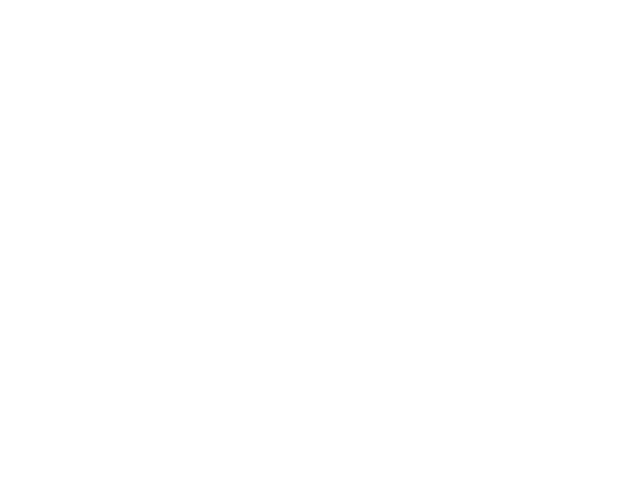

In [14]:
%matplotlib widget
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

# Define a common layout for the widgets
common_layout = widgets.Layout(width='500px', height='30px')
common_style = {'description_width': '200px'}

# Define the widgets
max_z_widget = widgets.FloatSlider(value=3, min=0.02, max=5, step=0.1, description='Max z (mm):', style=common_style, layout=common_layout)
min_z_widget = widgets.FloatSlider(value=0.02, min=0.02, max=1, step=0.02, description='Min z (mm):', style=common_style, layout=common_layout)
max_r_widget = widgets.FloatSlider(value=30, min=1, max=50, step=0.5, description='Max r (mm):', style=common_style, layout=common_layout)
min_r_widget = widgets.FloatSlider(value=2, min=0.5, max=10, step=0.5, description='Min r (mm):', style=common_style, layout=common_layout)
z_increase_factor_widget = widgets.FloatSlider(value=2, min=1, max=10, step=0.1, description='z Increase Factor:', style=common_style, layout=common_layout)
r_increase_factor_widget = widgets.FloatSlider(value=1.5, min=1, max=10, step=0.1, description='r Increase Factor:', style=common_style, layout=common_layout)
surface_charge_widget = widgets.IntSlider(value=3, min=1, max=10, step=1, description='Surface Charge (values):', style=common_style, layout=common_layout)
points_in_e_widget = widgets.IntSlider(value=15, min=1, max=1000, step=1, description='Points in Energy (values):', style=common_style, layout=common_layout)
runtime_per_sim_widget = widgets.FloatSlider(value=5, min=3, max=30, step=0.1, description='Run Time per Sim (min):', style=common_style, layout=common_layout)

def calculate_and_plot(max_z, max_r, min_z, min_r, z_increase_factor, r_increase_factor, surface_charge, points_in_e, runtime_per_sim):
    # Calculate z values
    z = min_z
    z_values = []
    while z <= max_z:
        z_values.append(z)
        z *= z_increase_factor
        
    # Calculate r values
    r = min_r
    r_values = []
    while r <= max_r:
        r_values.append(r)
        r *= r_increase_factor
        
    total_sims = len(z_values) * len(r_values) * surface_charge * points_in_e
    total_runtime = total_sims * runtime_per_sim
    print("Z values are:", z_values)
    print("R values are:", r_values)
    print(f"Total simulations: {total_sims}")
    print(f"Total run time: {total_runtime} minutes")
    print(f"Total run time: {total_runtime/(60*24):.2f} days")

    # Clear the previous plot and set up a new plot
    plt.clf()
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(np.tile(r_values, len(z_values)), np.repeat(z_values, len(r_values)), 'o', color='tab:blue', markersize=4)
    ax.set_xlabel('Radius (r) values')
    ax.set_ylabel('Height (z) values')
    ax.set_title('Scatter plot of r and z values')
    ax.grid(True)
    plt.show()

interactive_widget = widgets.interactive(calculate_and_plot, 
                                         max_z=max_z_widget, 
                                         min_z=min_z_widget, 
                                         max_r=max_r_widget, 
                                         min_r=min_r_widget, 
                                         z_increase_factor=z_increase_factor_widget,
                                         r_increase_factor=r_increase_factor_widget,
                                         surface_charge=surface_charge_widget, 
                                         points_in_e=points_in_e_widget, 
                                         runtime_per_sim=runtime_per_sim_widget)
display(interactive_widget)

In [15]:
import numpy as np

max_z = 5.5
min_z = 0.02
height = min_z
height_steps = []

# Generate z values
while height <= max_z:
    height_steps.append(round(height, 2))  # Round to two decimal places
    height *= 2

# Generate r values
max_r = 35
min_r = 2
r_values = np.arange(min_r, max_r + min_r, 3)
r_values = np.round(r_values, 2)  # Round r values to two decimal places

# Print z values
print("z points:", height_steps)
print("Number of z points:", len(height_steps))

# Print r values formatted with two decimal places
for r in r_values:
    print(f"{r:.2f}", end=", ")
print("\nNumber of r points:", len(r_values))

z points: [0.02, 0.04, 0.08, 0.16, 0.32, 0.64, 1.28, 2.56, 5.12]
Number of z points: 9
2.00, 5.00, 8.00, 11.00, 14.00, 17.00, 20.00, 23.00, 26.00, 29.00, 32.00, 35.00, 
Number of r points: 12



We have a maps for the biggest detector and most frequent detector for each type. Now we want to interpolate other detectors of smae type using them. We also want to make usre to it points that the geometry does not allowed. 
For ppc we want to scale using activensss(r,z) = r_small * activenss_big(r,z)/r_big. 
For Mirion ICPC and Bege detectors:
- if r>wrap_around_radius-ditch_thickness and r < wrap_around_radius activensss(r,z) = activenss_big(r,z) * r_small*wrap_around_radius ( small detector - ditch_thickness (small detector)/ (wrap_around_radius (large detector) - ditch_thickness (large detector))
- else activensss(r,z) = r_small * activenss_big(r,z) /r_big

disallowed regions:
Hemisphere for point contact r = (0, pc_radius) and z= (0, pc_height). 
for BEGes and Ortect ICPC for all r > wrap around radius the z <  Li_thickness are not allowed
at the egdge there might a taper, from (radius- taper_length, 0) to (radius, taper_length)


we can get all the measurements from siggen config file at 
/nas/longleaf/home/kbhimani/EH-Drift/config_files/siggen_configs

Largest for PPC: P00661B

By interpolation we meand estimating the value at given r,z for the smaller detector based on the bigger detector. so that spacing for the samller detector should be the same

Detector name: P00662C for valid

In [16]:
import numpy as np
import matplotlib.pyplot as plt

import os, math
from tools import load_waveform_data, apply_trap_filter_to_df, compute_pickoff_values_and_plot_random, add_tail_slope_to_dataframe,calculate_tail_slope, query_and_plot_waveform
from scipy.interpolate import griddata
from matplotlib import cm
def extract_measurements(config_file):
    """
    Extract geometric and relevant parameters from the Siggen config file.
    This function will skip lines that don't contain valid numerical values.
    """
    measurements = {}
    try:
        with open(config_file, 'r') as file:
            for line in file:
                # Strip whitespace and split by spaces, and keep only the first two elements
                parts = line.strip().split()
                
                # Skip empty lines and comments
                if not parts or parts[0].startswith("#"):
                    continue

                # Check if there are at least two elements (key-value)
                if len(parts) >= 2:
                    key, value = parts[0], parts[1]
                    try:
                        # Only process relevant keys (e.g., lengths, radii, etc.)
                        if key in ['xtal_length', 'xtal_radius', 'pc_length', 'pc_radius', 'taper_length',
                                   'wrap_around_radius', 'ditch_depth', 'ditch_thickness', 'hole_length',
                                   'hole_radius', 'outer_taper_length', 'outer_taper_width', 'inner_taper_length',
                                   'inner_taper_width', 'taper_angle', 'Li_thickness', 'impurity_z0', 'impurity_gradient', 
                                   'xtal_HV', 'surface_drift_vel_factor', 'passivated_thickness', 'energy']:
                            # Convert the value to float and store it
                            measurements[key] = float(value)
                    except ValueError:
                        # Skip lines where the second part isn't a valid float
                        print(f"Skipping non-numeric line: {line.strip()}")
    except FileNotFoundError:
        print(f"Error: Config file not found: {config_file}")
    
    return measurements



def is_allowed_region(r, z, measurements):
    """
    Check if a given (r, z) point is in a disallowed region based on the measurements.
    """
    
    return True 
    pc_radius = measurements.get('pc_radius', 0)
    pc_length = measurements.get('pc_length', 0)
    wrap_around_radius = measurements.get('wrap_around_radius', 0)
    ditch_thickness = measurements.get('ditch_thickness', 0)
    taper_length = measurements.get('taper_length', 0)
    Li_thickness = measurements.get('Li_thickness', 0)  # Not all detectors have Li_thickness
    
    # Check point contact disallowed region (hemisphere)
    if r < pc_radius and z < pc_length:
        return False
    
    # Check BEGes and Ortec ICPC disallowed region
    if r > wrap_around_radius - ditch_thickness and z < Li_thickness:
        return False

    # Check taper at the edge of the detector
    if r >= wrap_around_radius - taper_length and z < taper_length:
        return False

    return True

def process_waveforms_for_activeness(detector_name, waveform_dir, rise, flat, pickoff):
    """
    Process waveform data for a given detector and compute activeness (energy estimates) using the trapezoidal filter.
    
    Parameters:
    - detector_name: Name of the detector.
    - waveform_dir: Directory containing waveform HDF5 files.
    - rise: Rise time for the trapezoidal filter.
    - flat: Flat time for the trapezoidal filter.
    - pickoff: Index to pick off the value from the filtered waveform.
    
    Returns:
    - A DataFrame containing the activeness estimates for each (r, z) point.
    """
    # Construct the path to the waveform directory
    detector_waveforms_path = os.path.join(waveform_dir, detector_name)
    
    # Ensure the directory exists
    if not os.path.exists(detector_waveforms_path):
        raise FileNotFoundError(f"Waveform directory not found for detector: {detector_waveforms_path}")
    
    # Load waveform data for the detector
    detector_waveforms = load_waveform_data(detector_waveforms_path)
    
    # Apply trapezoidal filter to compute energy estimates (activeness)
    compute_pickoff_values_and_plot_random(detector_waveforms, rise=rise, flat=flat, pickoff=pickoff, plot_random=False)
    # Select only relevant columns
    activeness_df = detector_waveforms[['r', 'z', 'energy_estimate']]
    
    return activeness_df


import numpy as np

def interpolate_activeness_from_df(activeness_df, measurements_big, measurements_small, interpolation_type='ppc'):
    """
    Interpolate activeness based on the activeness of a larger detector and the measurements of the smaller one.
    
    Parameters:
    - activeness_df: DataFrame containing the activeness (r, z, energy_estimate) for the larger detector.
    - measurements_big: Dictionary of measurements for the larger detector (e.g., xtal_radius, xtal_length).
    - measurements_small: Dictionary of measurements for the smaller detector.
    - interpolation_type: Type of interpolation to apply (e.g., 'ppc', 'icpc', 'bege').
    
    Returns:
    - A DataFrame with interpolated activeness for the smaller detector, rounded to the nearest 1 decimal place.
    """
    # Create a new DataFrame to store the interpolated activeness values
    interpolated_activeness_df = activeness_df.copy()

    # Get measurements for big and small detectors
    r_big = measurements_big['xtal_radius']
    r_small = measurements_small['xtal_radius']
    wrap_around_big = measurements_big['wrap_around_radius']
    wrap_around_small = measurements_small['wrap_around_radius']
    ditch_thickness_big = measurements_big['ditch_thickness']
    ditch_thickness_small = measurements_small['ditch_thickness']

    print('r_small', r_small)
    print('r_big', r_big)

    if interpolation_type == 'ppc':
        # PPC: Scale by the ratio of the radii
        for index, row in activeness_df.iterrows():
            r_big_detector = row['r']
            activeness_big = row['energy_estimate']

            # Scale r for small detector
            r_small_detector = r_big_detector * r_small / r_big
            
            # Round to the nearest 1 decimal place
            r_small_detector_rounded = round(r_small_detector, 1)
            
            # Update interpolated dataframe
            interpolated_activeness_df.at[index, 'r'] = r_small_detector_rounded
            interpolated_activeness_df.at[index, 'energy_estimate'] = activeness_big  # Adjust activeness as needed

    elif interpolation_type == 'icpc':
        # ICPC: Scale based on ditch or non-ditch region
        for index, row in activeness_df.iterrows():
            r_big_detector = row['r']
            activeness_big = row['energy_estimate']

            # **Condition 1**: If `r < RO - WO` (Region before the ditch)
            if r_big_detector < wrap_around_big - ditch_thickness_big:
                # Regular radial scaling
                r_small_detector = r_big_detector * r_small / r_big

            # **Condition 2**: If `RO - WO <= r <= RO` (Ditch region)
            elif (wrap_around_big - ditch_thickness_big) <= r_big_detector <= wrap_around_big:
                # Special scaling in the ditch region
                r_small_detector = r_big_detector * (wrap_around_small / wrap_around_big)

            # **Condition 3**: If `r > RO` (Region beyond the wrap-around)
            else:
                # Regular radial scaling resumes
                r_small_detector = r_big_detector * r_small / r_big

            # Round to the nearest 1 decimal place
            r_small_detector_rounded = round(r_small_detector, 1)

            # Update interpolated dataframe
            interpolated_activeness_df.at[index, 'r'] = r_small_detector_rounded
            interpolated_activeness_df.at[index, 'energy_estimate'] = activeness_big  # Adjust activeness as needed

    return interpolated_activeness_df

def plot_interpolated_activeness_map(actual_activeness_df, grid_size=500):
    """
    Plot an interpolated activeness map using griddata interpolation and display the results on a heatmap.
    
    Parameters:
    - actual_activeness_df: DataFrame containing actual activeness data (r, z, energy_estimate).
    - grid_size: Size of the grid for interpolation.
    """
    
    # Extract r, z, and energy estimate for plotting
    r_plot = actual_activeness_df['r'].to_numpy()
    z_plot = actual_activeness_df['z'].to_numpy()
    energy_estimate = actual_activeness_df['energy_estimate'].to_numpy()

    # Create a grid for interpolation
    r_lin = np.linspace(r_plot.min(), r_plot.max(), grid_size)
    z_lin = np.linspace(z_plot.min(), z_plot.max(), grid_size)
    r_grid, z_grid = np.meshgrid(r_lin, z_lin)

    # Interpolate the data using 'cubic' method
    energy_interp = griddata((r_plot, z_plot), energy_estimate, (r_grid, z_grid), method='cubic')

    # Clip the interpolated energy to avoid extreme values
    energy_interp_clipped = np.clip(energy_interp, 0, 1)

    # Create heatmap
    plt.figure(figsize=(10, 6))
    heatmap = plt.pcolormesh(r_grid, z_grid, energy_interp_clipped, cmap=cm.viridis)
    plt.colorbar(heatmap, label='Activeness')
    plt.xlabel('Radius (mm)')
    plt.ylabel('Height (mm)')
    plt.title('Actual Activeness Map for P00662C')

    # Set the x-axis limit to the crystal radius minus the taper length
    plt.xlim([r_plot.min(), r_grid.max()])
    plt.ylim([z_plot.min(), z_plot.max()])

    # Display the plot
    plt.show()


def compare_actual_and_interpolated_activeness(actual_activeness_df, interpolated_activeness_df, grid_size=500):
    """
    Compare actual and interpolated activeness by plotting the difference.
    
    Parameters:
    - actual_activeness_df: DataFrame containing actual activeness data (r, z, energy_estimate).
    - interpolated_activeness_df: DataFrame containing interpolated activeness data (r, z, energy_estimate).
    - grid_size: Size of the grid for interpolation.
    """
    
    # Extract r, z, and energy estimate for both actual and interpolated data
    actual_r = actual_activeness_df['r'].to_numpy()
    actual_z = actual_activeness_df['z'].to_numpy()
    actual_energy = actual_activeness_df['energy_estimate'].to_numpy()

    interpolated_r = interpolated_activeness_df['r'].to_numpy()
    interpolated_z = interpolated_activeness_df['z'].to_numpy()
    interpolated_energy = interpolated_activeness_df['energy_estimate'].to_numpy()

    # Create a common grid
    r_lin = np.linspace(min(actual_r.min(), interpolated_r.min()), max(actual_r.max(), interpolated_r.max()), grid_size)
    z_lin = np.linspace(min(actual_z.min(), interpolated_z.min()), max(actual_z.max(), interpolated_z.max()), grid_size)
    r_grid, z_grid = np.meshgrid(r_lin, z_lin)

    # Interpolate both datasets onto the common grid
    actual_interp = griddata((actual_r, actual_z), actual_energy, (r_grid, z_grid), method='cubic')
    interpolated_interp = griddata((interpolated_r, interpolated_z), interpolated_energy, (r_grid, z_grid), method='cubic')

    # Compute percent difference
    percent_diff = 100 * np.abs((actual_interp - interpolated_interp) / np.maximum(actual_interp, 1e-9))  # Avoid division by zero

    bins = np.linspace(-2,100,500)
    plt.hist(percent_diff[percent_diff>0], bins=bins)
    plt.show()
    # Plot the percent difference
    plt.figure(figsize=(10, 6))
    diff_plot = plt.pcolormesh(r_grid, z_grid, percent_diff, cmap=cm.jet)
    plt.colorbar(diff_plot, label='Percent Difference (%)')
    plt.xlabel('Radius (mm)')
    plt.ylabel('Height (mm)')
    plt.title('Percent Difference Between Actual and Interpolated Activeness for P00662C')

    # Set the x-axis limit to the crystal radius minus the taper length
    plt.xlim([r_grid.min(), r_grid.max()]) #r_grid.max()
    plt.ylim([z_grid.min(), z_grid.max()])
    plt.show()

100%|██████████| 1/1 [00:00<00:00, 18.54it/s]


r_small 36.0
r_big 32.0


100%|██████████| 1/1 [00:00<00:00, 17.12it/s]


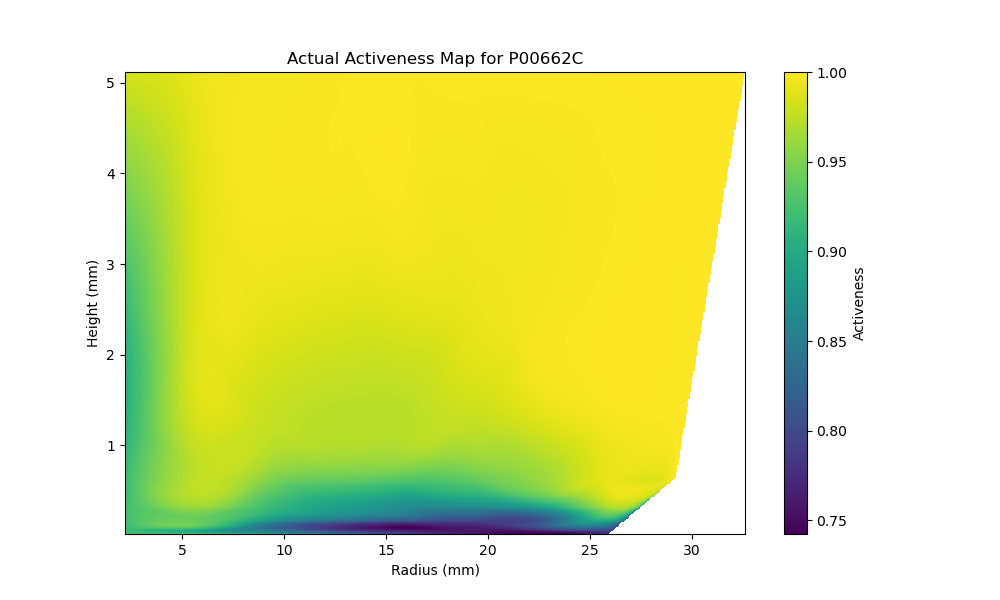

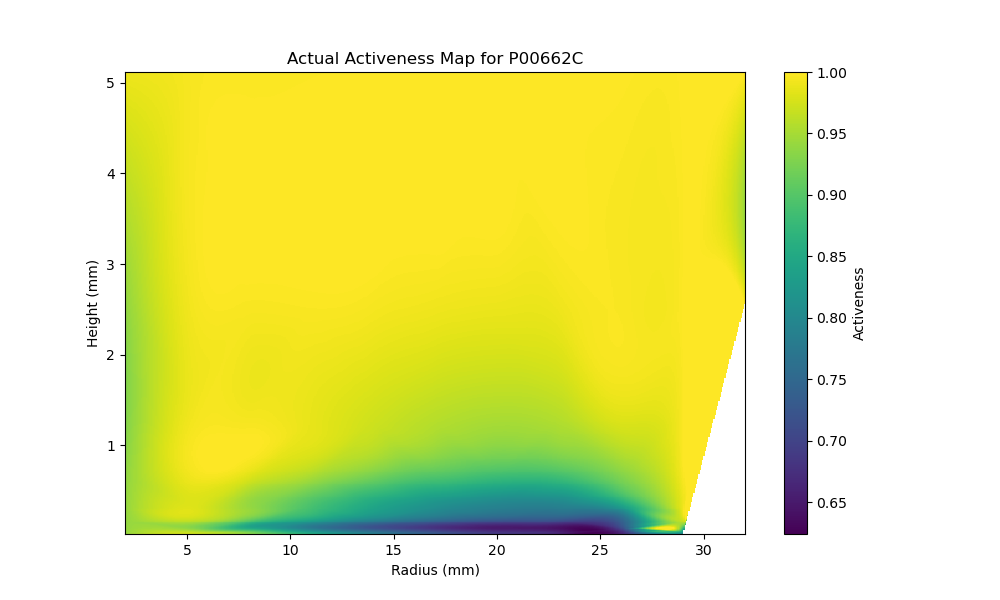

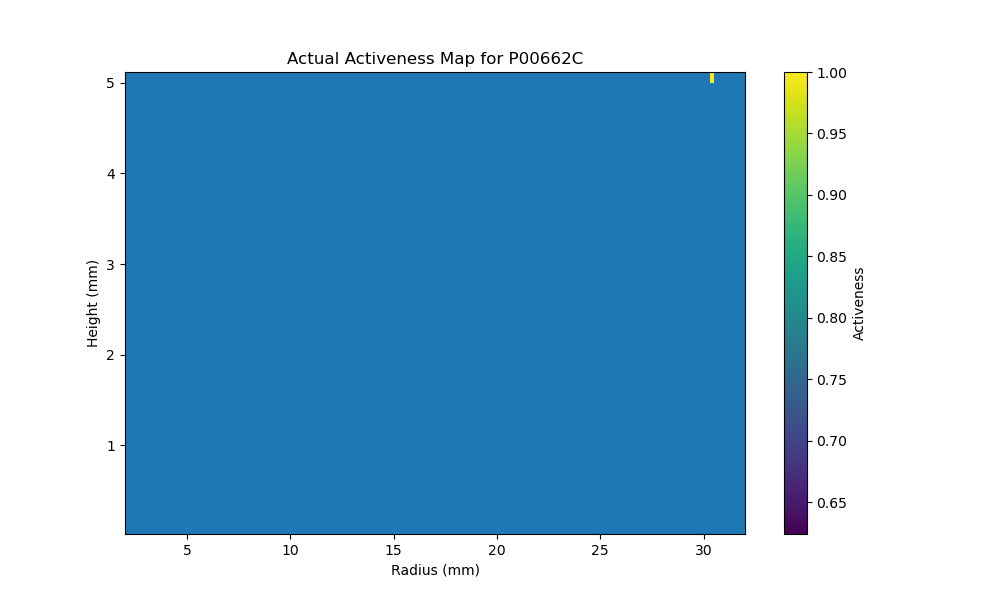

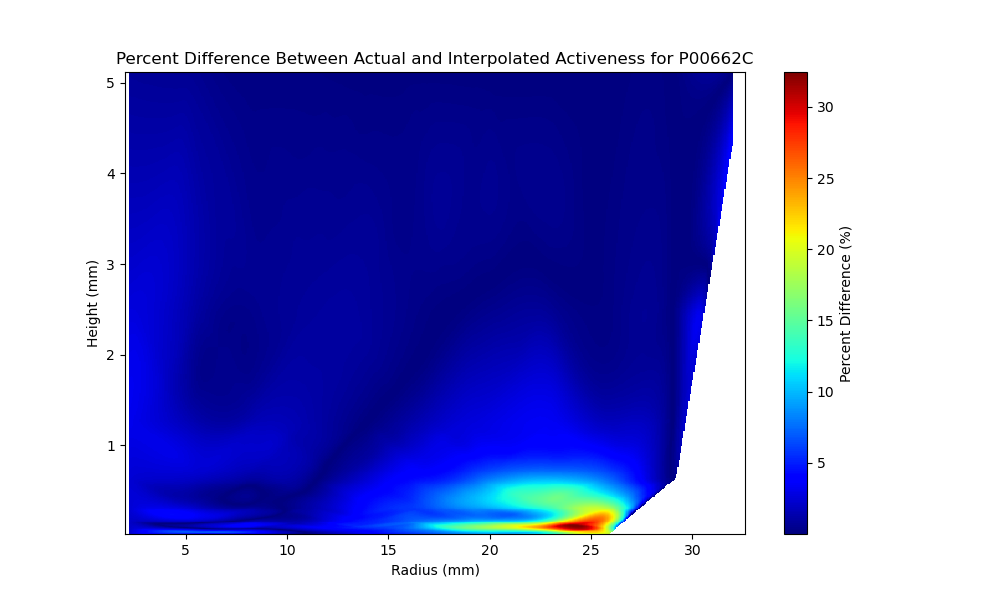

In [17]:
detector_name = 'P00661B'  #smallest P00662C
interpolate_from_detector = 'P00749A' # Detector for which we are calculating activeness #Biggest = P00661B_siggen, most frequent= P00749A
config_dir = '/nas/longleaf/home/kbhimani/EH-Drift/config_files/siggen_configs/'
waveforms_dir = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/'

# Ensure that the waveform and config directories exist
if not os.path.exists(config_dir):
    raise FileNotFoundError(f"Config directory not found: {config_dir}")
if not os.path.exists(waveforms_dir):
    raise FileNotFoundError(f"Waveform directory not found: {waveforms_dir}")

# Load activeness from waveforms (for the smaller detector)
rise = math.floor(10000 / 16)
flat = math.floor(3000 / 16)
pickoff = math.floor(13000 / 16)


# Load measurements for the largest detector
measurements_big = extract_measurements(os.path.join(config_dir, f'{interpolate_from_detector}_siggen.config')) 
# Load measurements for the smaller detector
measurements_small = extract_measurements(os.path.join(config_dir, f'{detector_name}_siggen.config'))


activeness_df = process_waveforms_for_activeness(interpolate_from_detector, waveforms_dir, rise, flat, pickoff)

# Interpolate activeness based on the large detector's data
interpolated_activeness_df = interpolate_activeness_from_df(activeness_df, measurements_big, measurements_small, interpolation_type='ppc')


actual_activeness_df = process_waveforms_for_activeness(detector_name, waveforms_dir, rise, flat, pickoff)


# Plot actual activeness map with limits adjusted based on geometry
plot_interpolated_activeness_map(interpolated_activeness_df)


# Plot actual activeness map with limits adjusted based on geometry
plot_interpolated_activeness_map(actual_activeness_df)

# Compare actual and interpolated activeness
compare_actual_and_interpolated_activeness(actual_activeness_df, interpolated_activeness_df)




In [18]:
#smallest_groove_radius_detector name: V00048B 
#largest_groove_radius_detector name: V04549B
#most_frequent_groove_radius_detector name: V00048A
# Detector names
detector_name = 'V04549B'  # Largest groove radius detector
interpolate_from_detector = 'V00048A'  # Most frequent groove radius detector
config_dir = '/nas/longleaf/home/kbhimani/EH-Drift/config_files/siggen_configs/'
waveforms_dir = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/'



# Load waveform data and measurements for the detectors
rise = math.floor(10000 / 16)
flat = math.floor(3000 / 16)
pickoff = math.floor(13000 / 16)

# Load activeness for the most frequent groove radius detector (V00048A)
activeness_df = process_waveforms_for_activeness(interpolate_from_detector, waveforms_dir, rise, flat, pickoff)
measurements_big = extract_measurements(os.path.join(config_dir, f'{interpolate_from_detector}_siggen.config'))
measurements_small = extract_measurements(os.path.join(config_dir, f'{detector_name}_siggen.config'))

# Interpolate activeness for the largest groove radius detector
interpolated_activeness_df = interpolate_activeness_from_df(activeness_df, measurements_big, measurements_small, interpolation_type='icpc')

# Load actual activeness for the largest groove radius detector (V04549B)
actual_activeness_df = process_waveforms_for_activeness(detector_name, waveforms_dir, rise, flat, pickoff)

# Compare actual and interpolated activeness
compare_actual_and_interpolated_activeness(actual_activeness_df, interpolated_activeness_df)

100%|██████████| 1/1 [00:00<00:00, 27.30it/s]


r_small 37.5
r_big 37.3


FileNotFoundError: Waveform directory not found for detector: /nas/longleaf/home/kbhimani/EH-Drift/waveforms/V04549B

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.interpolate import griddata
from matplotlib import cm

def plot_interpolated_activeness_map_icpc(actual_activeness_df, measurements, grid_size=500):
    """
    Plot an interpolated activeness map for ICPC detectors, with masked regions: ditch and Li_thickness.
    
    Parameters:
    - actual_activeness_df: DataFrame containing actual activeness data (r, z, energy_estimate).
    - measurements: Dictionary containing detector geometry (wrap_around_radius, ditch_thickness, ditch_depth, Li_thickness).
    - grid_size: Size of the grid for interpolation.
    """
    
    # Extract r, z, and energy estimate for plotting
    r_plot = actual_activeness_df['r'].to_numpy()
    z_plot = actual_activeness_df['z'].to_numpy()
    energy_estimate = actual_activeness_df['energy_estimate'].to_numpy()

    # Create a grid for interpolation
    r_lin = np.linspace(r_plot.min(), r_plot.max(), grid_size)
    z_lin = np.linspace(z_plot.min(), z_plot.max(), grid_size)
    r_grid, z_grid = np.meshgrid(r_lin, z_lin)

    # Interpolate the data using 'cubic' method
    energy_interp = griddata((r_plot, z_plot), energy_estimate, (r_grid, z_grid), method='cubic')

    # Clip the interpolated energy to avoid extreme values
    energy_interp_clipped = np.clip(energy_interp, 0, 1)

    # Create heatmap
    plt.figure(figsize=(10, 6))
    heatmap = plt.pcolormesh(r_grid, z_grid, energy_interp_clipped, cmap=cm.viridis)
    plt.colorbar(heatmap, label='Activeness')
    plt.xlabel('Radius (mm)')
    plt.ylabel('Height (mm)')
    plt.title('Interpolated Activeness Map for ICPC Detector')

    # Extract measurement parameters
    wrap_around_radius = measurements['wrap_around_radius']
    ditch_thickness = measurements['ditch_thickness']
    ditch_depth = measurements['ditch_depth']
    Li_thickness = measurements['Li_thickness']

    # Mask 1: Ditch region (white rectangle)
    r_start_ditch = wrap_around_radius - ditch_thickness
    r_end_ditch = wrap_around_radius
    z_start_ditch = 0
    z_end_ditch = ditch_depth

    # plt.gca().add_patch(Rectangle((r_start_ditch, z_start_ditch), r_end_ditch - r_start_ditch, z_end_ditch - z_start_ditch, color='white', zorder=2))
    plt.gca().add_patch(Rectangle((8, 0), 4, z_end_ditch, color='white', zorder=2))

    # Mask 2: Li_thickness region (white rectangle)
    r_start_Li = wrap_around_radius
    r_end_Li = r_plot.max()
    z_start_Li = 0
    z_end_Li = Li_thickness

    plt.gca().add_patch(Rectangle((12, 0), r_end_Li, z_end_Li, color='white', zorder=2))

    # Set plot limits
    plt.xlim([r_plot.min(), r_plot.max()])
    plt.ylim([z_plot.min(), z_plot.max()])

    # Display the plot
    plt.show()


In [ ]:
# Load measurements for V04549B detector (largest groove radius)
measurements = extract_measurements(os.path.join(config_dir, 'V04549B_siggen.config'))

# Plot the interpolated activeness map for the ICPC detector with ditch region masked
plot_interpolated_activeness_map_icpc(actual_activeness_df, measurements)

